# **Lab 4: Loss Function Comparison Experiment**
---
### **Comparing Mean Squared Error (MSE) vs. Mean Absolute Error (MAE) in Simple Regression**
---
**Deep Learning & GenAI 2026-27 V-B**  
**Name:** Ojasv Singh  
**University Roll No.:** 202401100500120  
**CSIT - B**

---
### **Objective:**
1. Implement a simple Linear Regression model ($\hat{y} = w \cdot x + b$) from scratch using gradient descent.
2. Define and compare two fundamental loss functions: **Mean Squared Error (MSE)** and **Mean Absolute Error (MAE)**.
3. Observe how each loss function impacts parameter updates, convergence behavior, and sensitivity to data outliers.
4. Plot and analyze **Loss Convergence Curves**, **Fitted Regression Lines**, **Error Residual Plots**, and **Loss Penalty Surfaces**.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Visualization styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
np.random.seed(42)


## **1. Mathematical Formulation & Gradients**

For a predicted value $\hat{y}_i = w \cdot x_i + b$ and true target $y_i$:

### **A. Mean Squared Error (MSE)**
- **Loss Equation:**  
  $$L_{\text{MSE}} = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2$$
- **Gradients:**  
  $$\frac{\partial L_{\text{MSE}}}{\partial w} = \frac{2}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i) \cdot x_i$$  
  $$\frac{\partial L_{\text{MSE}}}{\partial b} = \frac{2}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)$$

### **B. Mean Absolute Error (MAE)**
- **Loss Equation:**  
  $$L_{\text{MAE}} = \frac{1}{N} \sum_{i=1}^{N} |\hat{y}_i - y_i|$$
- **Gradients:**  
  $$\frac{\partial L_{\text{MAE}}}{\partial w} = \frac{1}{N} \sum_{i=1}^{N} \text{sign}(\hat{y}_i - y_i) \cdot x_i$$  
  $$\frac{\partial L_{\text{MAE}}}{\partial b} = \frac{1}{N} \sum_{i=1}^{N} \text{sign}(\hat{y}_i - y_i)$$  
  *(where $\text{sign}(e) = +1$ if $e > 0$, $-1$ if $e < 0$, and $0$ if $e = 0$)*


## **2. Dataset Creation with Outliers**
To clearly observe the difference between MSE and MAE:
1. Generate synthetic linear data: $y = 2x + 3 + \text{Gaussian Noise}$.
2. Inject a few **outliers** (extreme noisy points) to demonstrate how MSE (quadratic penalty) pulls the regression line towards outliers compared to MAE (linear penalty).


In [2]:
# Generate clean linear data with small gaussian noise
X = np.linspace(-3, 3, 30)
y_clean = 2.0 * X + 3.0
noise = np.random.normal(0, 0.4, size=X.shape)
y = y_clean + noise

# Introduce strong outliers
outlier_indices = [5, 24]
y[outlier_indices[0]] += 8.0  # Large positive outlier
y[outlier_indices[1]] -= 7.0  # Large negative outlier

print(f"Generated {len(X)} data points with {len(outlier_indices)} injected outliers.")
print("Sample X:", np.round(X[:5], 2))
print("Sample y:", np.round(y[:5], 2))


Generated 30 data points with 2 injected outliers.
Sample X: [-3.   -2.79 -2.59 -2.38 -2.17]
Sample y: [-2.8  -2.64 -1.91 -1.15 -1.44]


## **3. Model Implementation & Training Functions**
We define training loops for MSE and MAE loss using standard Gradient Descent.


In [3]:
# Initial parameters (identical starting point for fair comparison)
w_init, b_init = 0.0, 0.0

def train_mse(X, y, epochs=1000, lr=0.01):
    w, b = w_init, b_init
    loss_history = []
    
    N = len(X)
    for epoch in range(epochs):
        y_pred = w * X + b
        loss = np.mean((y_pred - y) ** 2)
        loss_history.append(loss)
        
        # Gradients
        dw = (2 / N) * np.sum((y_pred - y) * X)
        db = (2 / N) * np.sum(y_pred - y)
        
        # Gradient descent update
        w -= lr * dw
        b -= lr * db
        
    return w, b, loss_history

def train_mae(X, y, epochs=1000, lr=0.02):
    w, b = w_init, b_init
    loss_history = []
    
    N = len(X)
    for epoch in range(epochs):
        y_pred = w * X + b
        loss = np.mean(np.abs(y_pred - y))
        loss_history.append(loss)
        
        # Gradients (sign function)
        errors = y_pred - y
        dw = (1 / N) * np.sum(np.sign(errors) * X)
        db = (1 / N) * np.sum(np.sign(errors))
        
        # Gradient descent update
        w -= lr * dw
        b -= lr * db
        
    return w, b, loss_history

# Train models
w_mse, b_mse, loss_hist_mse = train_mse(X, y, epochs=1000, lr=0.01)
w_mae, b_mae, loss_hist_mae = train_mae(X, y, epochs=1000, lr=0.02)

print("=== MSE Model Results ===")
print(f"Final Weights: w = {w_mse:.4f}, b = {b_mse:.4f}")
print(f"Final MSE Loss: {loss_hist_mse[-1]:.4f}")

print("\n=== MAE Model Results ===")
print(f"Final Weights: w = {w_mae:.4f}, b = {b_mae:.4f}")
print(f"Final MAE Loss: {loss_hist_mae[-1]:.4f}")


=== MSE Model Results ===
Final Weights: w = 1.6256, b = 2.9581
Final MSE Loss: 3.4980

=== MAE Model Results ===
Final Weights: w = 1.9270, b = 2.9720
Final MAE Loss: 0.7593


## **4. Visualization 1: Loss Surface / Penalty Functions**
Before looking at fit results, let's visualize how MSE vs. MAE penalizes prediction error $e = (y - \hat{y})$.
- **MSE Error Curve ($e^2$):** Penalizes small errors gently, but penalizes large errors quadratically.
- **MAE Error Curve ($|e|$):** Penalizes all errors proportionally/linearly, regardless of error magnitude.


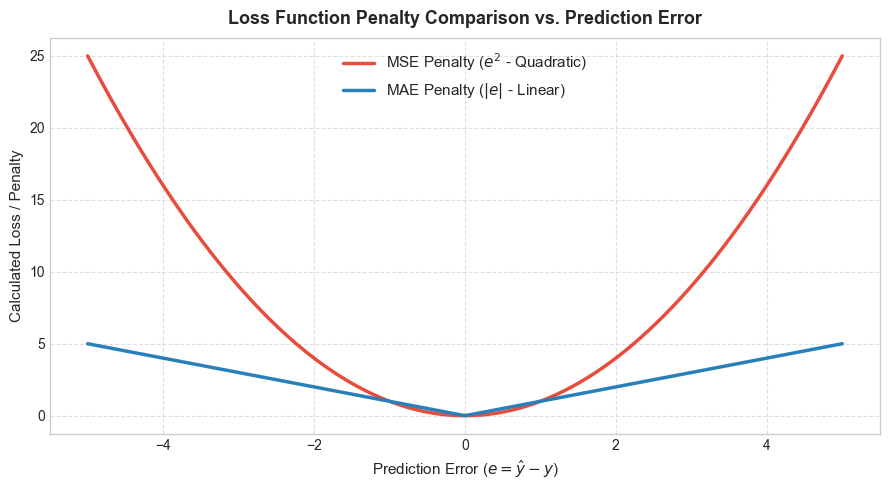

In [4]:
error_range = np.linspace(-5, 5, 200)
mse_penalty = error_range ** 2
mae_penalty = np.abs(error_range)

plt.figure(figsize=(9, 5))
plt.plot(error_range, mse_penalty, label='MSE Penalty ($e^2$ - Quadratic)', color='#e74c3c', linewidth=2.5)
plt.plot(error_range, mae_penalty, label='MAE Penalty ($|e|$ - Linear)', color='#2980b9', linewidth=2.5)
plt.title('Loss Function Penalty Comparison vs. Prediction Error', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Prediction Error ($e = \hat{y} - y$)', fontsize=11)
plt.ylabel('Calculated Loss / Penalty', fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## **5. Visual Comparison: Regression Line Fitting & Loss Convergence**
We plot:
1. **Fitted Regression Lines** compared against Ground Truth ($y = 2x + 3$) and Data Points with Outliers.
2. **Loss Convergence Graphs** over training epochs.


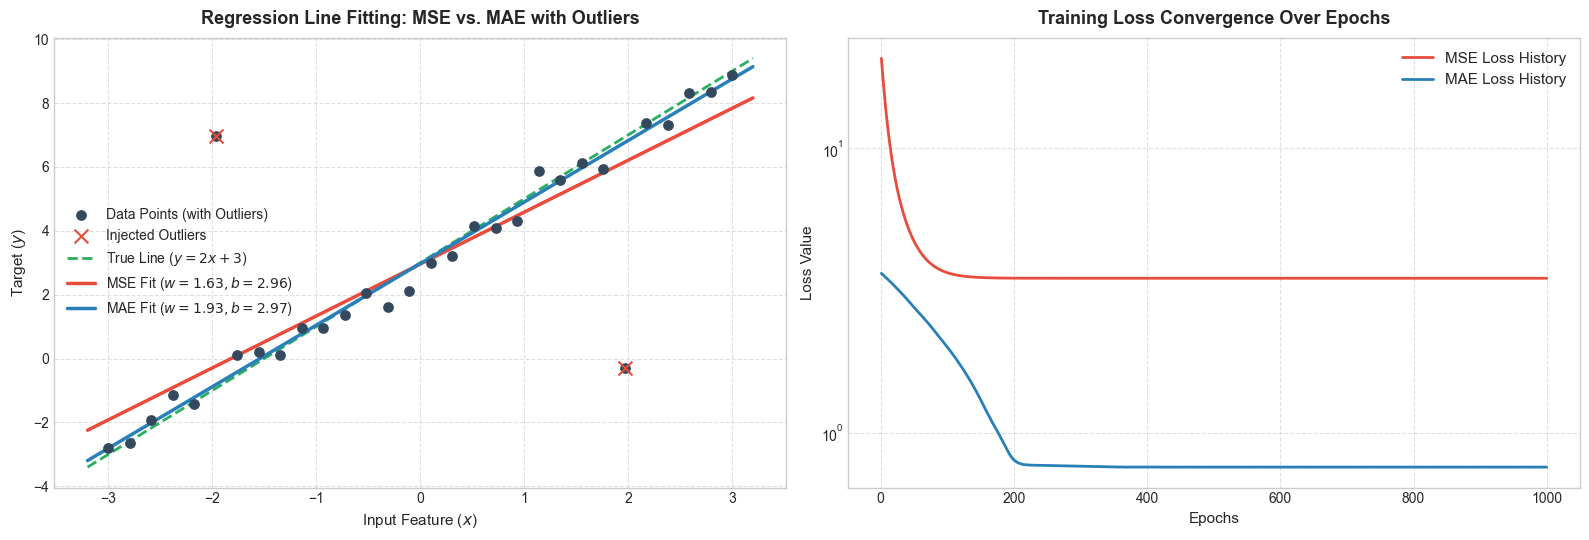

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Plot 1: Fitted Regression Lines vs Data Points
axes[0].scatter(X, y, color='#34495e', label='Data Points (with Outliers)', s=45, zorder=3)
axes[0].scatter(X[outlier_indices], y[outlier_indices], color='#e74c3c', s=100, label='Injected Outliers', zorder=4, marker='x')

# Ground truth line
X_line = np.linspace(-3.2, 3.2, 100)
axes[0].plot(X_line, 2.0 * X_line + 3.0, label='True Line ($y = 2x + 3$)', color='#27ae60', linestyle='--', linewidth=2)

# Fitted lines
axes[0].plot(X_line, w_mse * X_line + b_mse, label=f'MSE Fit ($w={w_mse:.2f}, b={b_mse:.2f}$)', color='#e74c3c', linewidth=2.5)
axes[0].plot(X_line, w_mae * X_line + b_mae, label=f'MAE Fit ($w={w_mae:.2f}, b={b_mae:.2f}$)', color='#2980b9', linewidth=2.5)

axes[0].set_title('Regression Line Fitting: MSE vs. MAE with Outliers', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Input Feature ($x$)', fontsize=11)
axes[0].set_ylabel('Target ($y$)', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Training Loss Convergence
epochs_range = range(1, 1001)
axes[1].plot(epochs_range, loss_hist_mse, label='MSE Loss History', color='#e74c3c', linewidth=2)
axes[1].plot(epochs_range, loss_hist_mae, label='MAE Loss History', color='#2980b9', linewidth=2)
axes[1].set_title('Training Loss Convergence Over Epochs', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Epochs', fontsize=11)
axes[1].set_ylabel('Loss Value', fontsize=11)
axes[1].set_yscale('log')  # Log scale for easy comparison
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


## **6. Residual Error Analysis**
We examine the residual error for each sample: $e_i = y_i - \hat{y}_i$.
Outliers create very large residual errors. Observing these residual plots highlights how MSE tilts the whole line to reduce extreme outlier errors, while MAE leaves in-lier residuals balanced around 0.


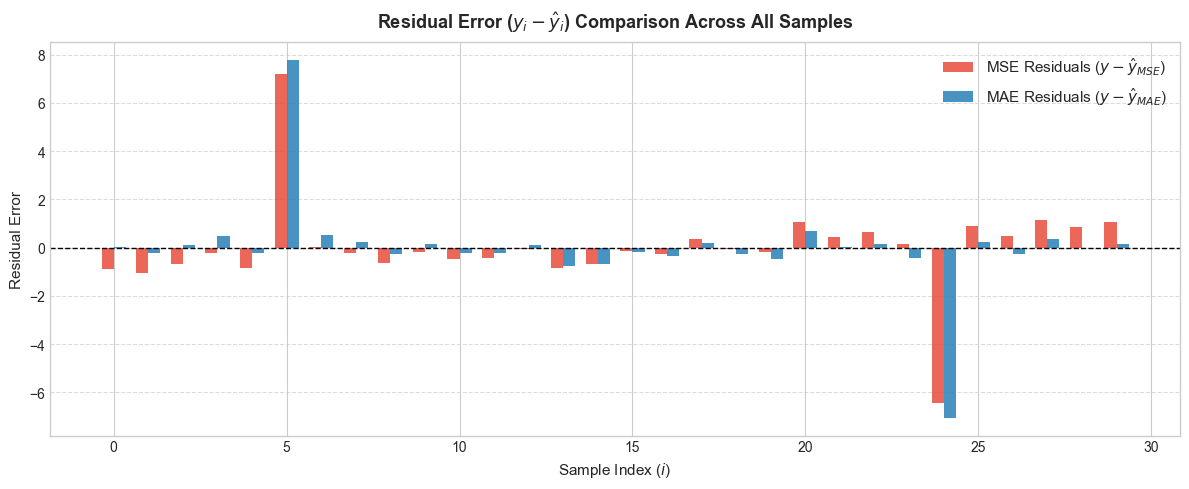

In [6]:
y_pred_mse = w_mse * X + b_mse
y_pred_mae = w_mae * X + b_mae

residuals_mse = y - y_pred_mse
residuals_mae = y - y_pred_mae

plt.figure(figsize=(12, 5))
indices = np.arange(len(X))
width = 0.35

plt.bar(indices - width/2, residuals_mse, width=width, label='MSE Residuals ($y - \hat{y}_{MSE}$)', color='#e74c3c', alpha=0.85)
plt.bar(indices + width/2, residuals_mae, width=width, label='MAE Residuals ($y - \hat{y}_{MAE}$)', color='#2980b9', alpha=0.85)

plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.title('Residual Error ($y_i - \hat{y}_i$) Comparison Across All Samples', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Sample Index ($i$)', fontsize=11)
plt.ylabel('Residual Error', fontsize=11)
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## **7. Summary & Key Insights**

| Property / Metric | Mean Squared Error (MSE) | Mean Absolute Error (MAE) |
| :--- | :--- | :--- |
| **Mathematical Formula** | $\frac{1}{N} \sum (\hat{y} - y)^2$ | $\frac{1}{N} \sum |\hat{y} - y|$ |
| **Gradient Magnitude** | Proportional to error size ($2(\hat{y} - y)$) | Constant magnitude ($\pm 1$) |
| **Sensitivity to Outliers** | **High** (Squaring creates massive penalty for outliers) | **Low / Robust** (Linear penalty treats outliers uniformly) |
| **Statistical Estimator** | Estimates the **Mean** of target distribution | Estimates the **Median** of target distribution |
| **Fitted Slope ($w$)** | Significantly distorted by outlier points | Closely tracks ground truth slope ($w \approx 2.0$) |

---

### **Core Takeaways:**
1. **Outlier Impact**: MSE squares error terms, making large errors dominant in gradient updates. As a result, the MSE regression line tilts significantly to reduce extreme outlier errors at the expense of overall in-lier accuracy.
2. **Robustness of MAE**: MAE uses absolute differences, resulting in constant gradient step sizes. Outliers contribute no more gradient force than in-liers, preserving the line fit closer to the true underlying pattern ($y = 2x + 3$).
3. **Gradient Stability**: MAE gradients jump abruptly from $+1$ to $-1$ at zero error (non-differentiable at $0$), which can cause slight oscillation near convergence, whereas MSE gradients smoothly scale to $0$ as errors shrink.
